# analysis.detection-statistics


## Summary 

In this notebook, we focus on the numbers generated by our bacteria-taxonomic profiling using MOTUs. We read mostly content from the `metadata.site-library.csv` files and from `hits.bacteria.csv`. We first carry out a bacteria / PAB based analysis, and then we carry out a library based analysis. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import taxoniq
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌─────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│        name         │                                                                                  description                                                                                   │
│       varchar       │                                                                                    varchar                                                                                     │
├─────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits      │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the library where the detection took place, taxid, scientific name and the PAB labe

## Bacteria

We carry out the analysis here by making questions and answering them.

### How many bacteria were detected?

To know that, first we need to load the data. 

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_bacteriaHits').df()
metadata = db.conn.sql('SELECT * FROM D_sites').df()

Now, we value count the different taxids. 

In [3]:
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left')#.dropna(subset='taxid')
# bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_hits

,site,library,habitat,n_extracts,host_taxon,taxid,scientific_name,is_pab,pab_type
0,C1,PV534,Crop,3,Diplotaxis erucoides,59620.0,uncultured Clostridium sp.,False,
1,C1,PV535,Crop,17,Brassica oleracea,1563157.0,Pseudomonas endophytica,True,pab_unknown
2,C1,PV535,Crop,17,Brassica oleracea,1270.0,Micrococcus luteus,True,pab_unknown
3,C1,PV535,Crop,17,Brassica oleracea,59620.0,uncultured Clostridium sp.,False,
4,C1,PV538,Crop,8,Brassica oleracea,82995.0,Serratia grimesii,False,
...,...,...,...,...,...,...,...,...,...
1512,Z2,PV529,Crop,1,Picris echioides,289370.0,Pseudomonas argentinensis,True,pab_unknown
1513,Z2,PV529,Crop,1,Picris echioides,1736265.0,Methylobacterium sp. Leaf125,True,pab_unknown
1514,Z2,PV529,Crop,1,Picris echioides,91844.0,Candidatus Portiera aleyrodidarum,False,
1515,Z2,PV529,Crop,1,Picris echioides,1192054.0,Paracoccus sp. 228,False,


The data contains hits. We need to aggregate the hits to get the OTUs to which they map, which we do by a simple `value_counts`. 

In [4]:
bacteria_hits_count = bacteria_hits.value_counts(['scientific_name']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits)
bacteria_hits_count

,scientific_name,count,rank,%
0,uncultured Clostridium sp.,258,1,0.170073
1,Frigoribacterium sp. Leaf164,26,2,0.017139
2,Rhodococcoides fascians,21,3,0.013843
3,Pseudomonas lutea,21,4,0.013843
4,Cutibacterium acnes,21,5,0.013843
...,...,...,...,...
515,Intrasporangiaceae bacterium URHB0013,1,516,0.000659
516,Hymenobacter terrenus,1,517,0.000659
517,Hymenobacter swuensis,1,518,0.000659
518,Hymenobacter sp. PAMC 26628,1,519,0.000659


In [5]:
bacteria_hits_count.query('scientific_name == ""')

,scientific_name,count,rank,%
22,,10,23,0.006592


In [6]:
print("Total hits {:6d}".format(len(bacteria_hits))) # 1486
print(" |--> corresponding to {:6d} bacterial OTUs".format(len(bacteria_hits_count))) # 522


Total hits   1517
 |--> corresponding to    520 bacterial OTUs


We have 1486 hits corresponding to 519 OTUs. Now, let's see how they distribute. 

In [7]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))}, # 311
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 211
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, # 113 
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 43
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 22
    ]
)



,threshold,count
0,=1,309
1,>1,211
2,>2,113
3,>5,43
4,>10,22


Most OTUs (> 300) have been detected only one. A ranking map of these OTUs should help us see this pattern. In the folllowing plot, we are sorting by growing rank the OTUs depending on their number of hits. On the left, we would find the OTUs with higher number of hits, on the right those with the lower number of hits. 

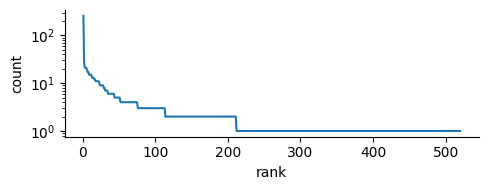

In [8]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.5
)
# g.ax.axvline(10, linestyle='--', color='gray')
g.ax.set_yscale('log')


We can observe indeed a very heterogeneous distribution, with some hits exceeding the 100 detections. Let's see which could be these organisms.

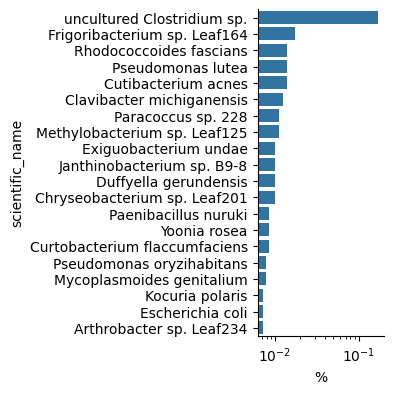

In [9]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar', height=4.0, aspect=1.0
)
g.ax.set_xscale('log')

This is quite interesting:
- The most abundant organism is an *uncultured Clostridium sp.*. This means that it could be whatever.
- After that one, we have some organism that are indeed known for interacting with plants such as *Pseudomonas lutea*.
- We also find unexpected items, such as *Escherichia coli* and *Mycoplasmoides genitalium*. This could mean that our samples are either contaminated by animal associated bacteria.

#### Conclussion

- 1486 hits
- 522 OTUs
- Very heterogeneous distribution
- There are some unexpected organisms

### How many bacteria are plant-associated-bacteria?

The way to solve this query is very easy: just remove the bacteria that are not PAB, and repeat the whole analysis. 

In [16]:
bacteria_hits_count = bacteria_hits.query('is_pab == True').value_counts(['taxid', 'scientific_name', 'pab_type']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits.query('is_pab == True'))
bacteria_hits_count

,taxid,scientific_name,pab_type,count,rank,%
0,1736282.0,Frigoribacterium sp. Leaf164,pab_unknown,26,1,0.060046
1,243924.0,Pseudomonas lutea,pab_unknown,21,2,0.048499
2,1828.0,Rhodococcoides fascians,pab_unknown,21,3,0.048499
3,1736265.0,Methylobacterium sp. Leaf125,pab_unknown,17,4,0.039261
4,1735672.0,Chryseobacterium sp. Leaf201,pab_unknown,15,5,0.034642
...,...,...,...,...,...,...
122,1144319.0,Herbaspirillum sp. CF444,pab_unknown,1,123,0.002309
123,1144310.0,Rhizobium sp. CF080,pab_symbiont,1,124,0.002309
124,1028989.0,Pseudomonas sp. StFLB209,pab_unknown,1,125,0.002309
125,582680.0,Microbacterium azadirachtae,pab_unknown,1,126,0.002309


In [17]:
print("Total PAB hits {:6d}".format(len(bacteria_hits.query('is_pab == True')))) # 433
print(" |--> corresponding to {:6d} PAB OTUs".format(len(bacteria_hits_count))) # 127


Total PAB hits    433
 |--> corresponding to    127 PAB OTUs


We have a total of 433 PAB hits, corresponding to 127 OTUs. These numbers might have been slightly higher in the past, given some errors when counting organisms. Let's take again one look at the count.

In [18]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))},# 53 
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 74
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, #45
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 20
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 9
    ]
)

,threshold,count
0,=1,53
1,>1,74
2,>2,45
3,>5,20
4,>10,9


The numbers are quite brutal again. Two fifths of the data have only one positive hit. Let's look at this again with a rank-plot. 

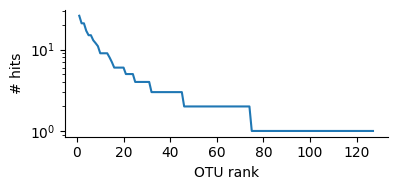

In [19]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("OTU rank")
g.set_ylabels("# hits")

g.savefig("figures/rankplot.pab-bacteria.svg")

Now we can take a quick look at the composition of these bacteria.

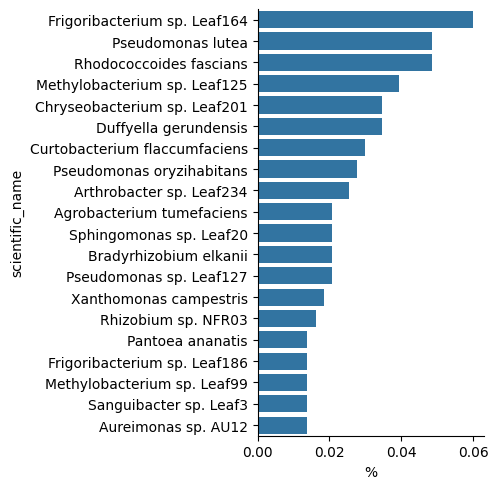

In [20]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar'
)
# g.ax.set_xscale('log')

### What is the high-level taxonomic composition of our PABs?

While we have the species represented in the plot above, higher-taxonomy levels might provide another picture. We will use Taxoniq to compute the taxon, class, order, etc of each of the taxa, and we will dump it in a figure. 

In [21]:
bacteria_hits_count['taxon'] = bacteria_hits_count['taxid'].apply(lambda x: taxoniq.Taxon(x))
bacteria_hits_count['class'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'class'][0])
bacteria_hits_count['order'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'order'][0])
bacteria_hits_count['phylum'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'phylum'][0])

The following figure should represent the phylum (color) and the order (row) of all the species detected. 

Saved P_PABtaxonomy to db.2025-10-27


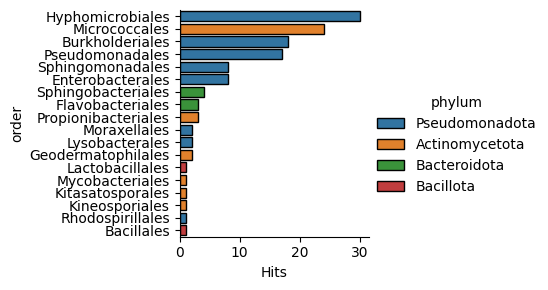

In [22]:
bacteria_taxonomies = bacteria_hits_count.value_counts(['order', 'phylum']).reset_index()

db.save_dataframe(
    bacteria_taxonomies, table_name="P_PABtaxonomy",
    description="Number of PAB hits belonging to each different phylum and order"
)
g = sns.catplot(bacteria_taxonomies, x='count', hue='phylum', y='order', kind='bar', edgecolor='black', height=3., aspect=1.5, dodge=False)
g.set_xlabels("Hits")
g.savefig("figures/catplot.detections-taxonomic-composition.colbyphyla.svg")

### What kind of PABs?

Sanchis et al. (2021) consider three types of PABs:
- *symbionts*, which we prefer to call *mutualists*
- *pathogens*, which we should call *antagonists* —but we won't.
- *unknown*, those that have an uncertain relationship with the hosts.

We are going to generate a table the considers the numbers of each of these PAB types among our OTUs.

In [23]:
pab_types = bacteria_hits_count.value_counts(['pab_type']).reset_index().rename(columns={'count': 'OTUs'})
db.save_dataframe(
    pab_types, table_name="D_PABTypeCounts",
    description="Occurrences of the different kinds of PABs"
)
pab_types

Saved D_PABTypeCounts to db.2025-10-27


,pab_type,OTUs
0,pab_unknown,96
1,pab_symbiont,17
2,pab_pathogen,14


## Libraries

Again, simple Q & A

### What is the distribution of hits across our libraries?

To answer this question, first we need to value-count the number of total hits per library. We all save the habitat. 

In [24]:
library_hits_count = bacteria_hits.value_counts(['library', 'site', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,site,habitat,count,rank
0,PV215,L3,Edge,139,0
1,PV527,Z2,Crop,105,1
2,PV078,E4,Wasteland,71,2
3,PV212,L3,Edge,52,3
4,PV218,L3,Edge,43,4
...,...,...,...,...,...
321,PV148,L3,Edge,1,321
322,PV151,L4,Edge,1,322
323,PV152,L4,Edge,1,323
324,PV153,L4,Edge,1,324


The following table indicates some values of the distribution.

In [25]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))}, #88
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))}, #211
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,111
1,>1,215
2,>2,133
3,>5,58
4,>10,22


We have 299 positive libraries out of the 323 libraries, which means 24 negatives. Only 22 libraries have more than 10 OTUs detected.

We use the following rank plot to visualize the heterogeneity of host ranges.

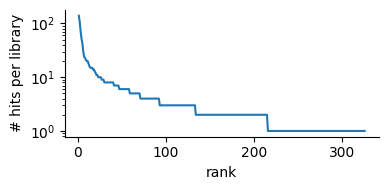

In [26]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot",
#     description="Ranking of sites depending on their detections"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("rank")
g.set_ylabels("# hits per library")

### How many PAB detections per library?

As simple as the analysis above, but just analyzing PAB hits.

In [27]:
library_hits_count = bacteria_hits.query('is_pab == True').value_counts(['library', 'site', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,site,habitat,count,rank
0,PV215,L3,Edge,43,0
1,PV078,E4,Wasteland,37,1
2,PV527,Z2,Crop,28,2
3,PV212,L3,Edge,14,3
4,PV525,Z1,Crop,10,4
...,...,...,...,...,...
131,PV083,Q1,Oak,1,131
132,PV075,E2,Wasteland,1,132
133,PV174,L2,Edge,1,133
134,PV069,E1,Wasteland,1,134


In [28]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))},
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))},
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,62
1,>1,74
2,>2,50
3,>5,14
4,>10,4


Only 136 libraries were positive to PABs.

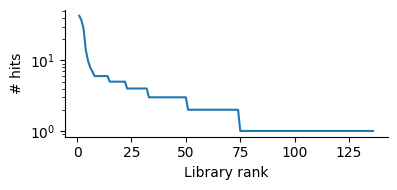

In [29]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot_PAB",
#     description="Ranking of sites depending on their detections of PAB OTUs"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("Library rank")
g.set_ylabels("# hits")
g.savefig("figures/rankplot.pab-library.svg")

## Conclussions

1. We are able to detect 1486 bacteria hits, corresponding to 522 OTUs.
2. From those, around one third of the hits correspond to plant-associated bacteria. The total PAB OTUs are 127.
3. Most of the hits correspond to the order hyphomicrobiales, microccocales, burkhlodeliares, and pseudomonareales #TODO: check spelling.
4. Only 136 libraries (around half of them) were positive to PABs.

In [30]:
db.conn.close()